# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn import linear_model
import matplotlib.pyplot as plt

You will need to predict the average delta between the deadlines
and the first commit for every user with data about their views of the newsfeed and the
number of commits they made during the program

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv("../data/checker_regression.csv").fillna(0)
display(df)

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,0.00
1,user_1,62,28.0,0.00
2,user_1,62,28.0,0.00
3,user_1,62,28.0,0.00
4,user_1,62,28.0,0.00
...,...,...,...,...
72,user_31,128,0.0,-104.75
73,user_4,40,0.0,-175.60
74,user_6,15,0.0,-62.60
75,user_7,8,0.0,-115.50


In [3]:
# закодируем uid
cols = ["uid"]
categorical_columns = df[cols] # объявляем какие колонки нужно закодировать
encoder = OneHotEncoder(sparse_output=False) # не возвращать разряженную матрицу
encoded_columns = encoder.fit_transform(categorical_columns)

one_hot_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(cols)) # создаем из полученных значений таблицу 
                                                                                        # с колонками под названиями columns
df = pd.concat([df, one_hot_df], axis=1)
df.drop(columns=cols, inplace=True)

# нормализуем num_commits и pageviews
scaler = StandardScaler()
df[["num_commits", "pageviews"]] = scaler.fit_transform(df[["num_commits", "pageviews"]])

display(df)

,num_commits,pageviews,AVG(diff),uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,...,uid_user_27,uid_user_28,uid_user_29,uid_user_3,uid_user_30,uid_user_31,uid_user_4,uid_user_6,uid_user_7,uid_user_8
0,0.406864,-0.476157,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.406864,-0.476157,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.406864,-0.476157,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.406864,-0.476157,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.406864,-0.476157,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,2.585669,-0.775718,-104.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
73,-0.319404,-0.775718,-175.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
74,-1.144708,-0.775718,-62.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
75,-1.375794,-0.775718,-115.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
X = df.drop(["AVG(diff)"], axis=1)
Y = df["AVG(diff)"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

__N-Fold (или N-кратная) кросс-валидация__ — это метод оценки качества модели в машинном обучении, который делит весь набор данных на N равные части (фолды). Процесс выглядит следующим образом:

1. Набор данных делится на N части. Это могут быть, например, случайно выбранные подмножества данных.

2. Модель обучается на N-1 из N частей данных, а затем тестируется на оставшейся части. Этот процесс повторяется N раза, при этом каждый раз используется другая часть данных для тестирования.

RMSE (Root Mean Square Error) = sqrt(1/n * Σ(y_i - ŷ_i)²)

In [5]:
Y_train.reset_index()

,index,AVG(diff)
0,11,0.0
1,42,0.0
2,8,0.0
3,1,0.0
4,7,0.0
...,...,...
56,35,0.0
57,48,0.0
58,4,0.0
59,56,0.0


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


def crossval(n_splits, X, y, model):
    """
    Проводит кросс-валидацию на n_splits наборов данных
    Высчитывает RMSE для полученного предстказания
    """

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)  # кросс валидация для n_splits
    test_rmse, train_rmse = [], 0

    for train_index, test_index in kf.split(X):  # итерация кросс-валидации
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, Y_train)
        Y_train_pred = model.predict(X_train)
        Y_test_pred = model.predict(X_test)

        train_rmse = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
        test_rmse.append(np.sqrt(mean_squared_error(Y_test, Y_test_pred)))

        print(f'train - {train_rmse}   |   test - {test_rmse[-1]}')

    avg_rmse = np.mean(test_rmse)
    print(f'Average RMSE  {avg_rmse}')
    return avg_rmse

X_train = X_train[["num_commits", "pageviews"]]
X_test = X_test[["num_commits", "pageviews"]]

reg = linear_model.LinearRegression()
crossval(10, X_train, Y_train, reg)


train - 43.85193506275826   |   test - 42.01528915581881
train - 41.801016176679624   |   test - 58.19069641798876
train - 44.69553999765828   |   test - 34.89272019343368
train - 38.84549642903112   |   test - 76.60149754412575
train - 44.860797582621885   |   test - 31.90431486867118
train - 44.855033493587875   |   test - 30.369016640380938
train - 42.07183083893711   |   test - 56.10331212526736
train - 45.6755157436544   |   test - 16.544000169395833
train - 43.60670981884092   |   test - 45.85548116615202
train - 44.2670184108396   |   test - 39.06886806726506
Average RMSE  43.15451963484993


43.15451963484993

In [7]:
tree = DecisionTreeRegressor(random_state=21)
crossval(10, X_train, Y_train, tree)

forest = RandomForestRegressor(random_state=21)
crossval(10, X_train, Y_train, forest)

train - 0.0   |   test - 7.634882354786397
train - 0.0   |   test - 54.46032194787933
train - 0.0   |   test - 33.47635981803677
train - 0.0   |   test - 60.36467571414655
train - 0.0   |   test - 19.187669651801563
train - 0.0   |   test - 23.43345187262574
train - 0.0   |   test - 23.117273483984512
train - 0.0   |   test - 73.25620691690125
train - 0.0   |   test - 60.09094072659711
train - 0.0   |   test - 46.33618096764845
Average RMSE  40.13579634544077
train - 14.388980213656279   |   test - 4.162396753092979
train - 13.742530328171256   |   test - 40.26362372976199
train - 13.46347922886055   |   test - 38.26198236161764
train - 11.642345978683757   |   test - 58.178615769949424
train - 14.137800551244434   |   test - 23.735827773095973
train - 14.97852050395411   |   test - 9.565665693858715
train - 14.805370579231832   |   test - 27.332911218962828
train - 12.17746310423687   |   test - 57.020533082065825
train - 13.495696250840465   |   test - 39.07289544200975
train - 13.60

33.15256002380287

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [8]:
reg = linear_model.LinearRegression()
tree = DecisionTreeRegressor(random_state=21)
forest = RandomForestRegressor(random_state=21)

In [9]:
reg.fit(X_train, Y_train)
tree.fit(X_train, Y_train)
forest.fit(X_train, Y_train)

reg_pred = reg.predict(X_test)
tree_pred = tree.predict(X_test)
forest_pred = forest.predict(X_test)

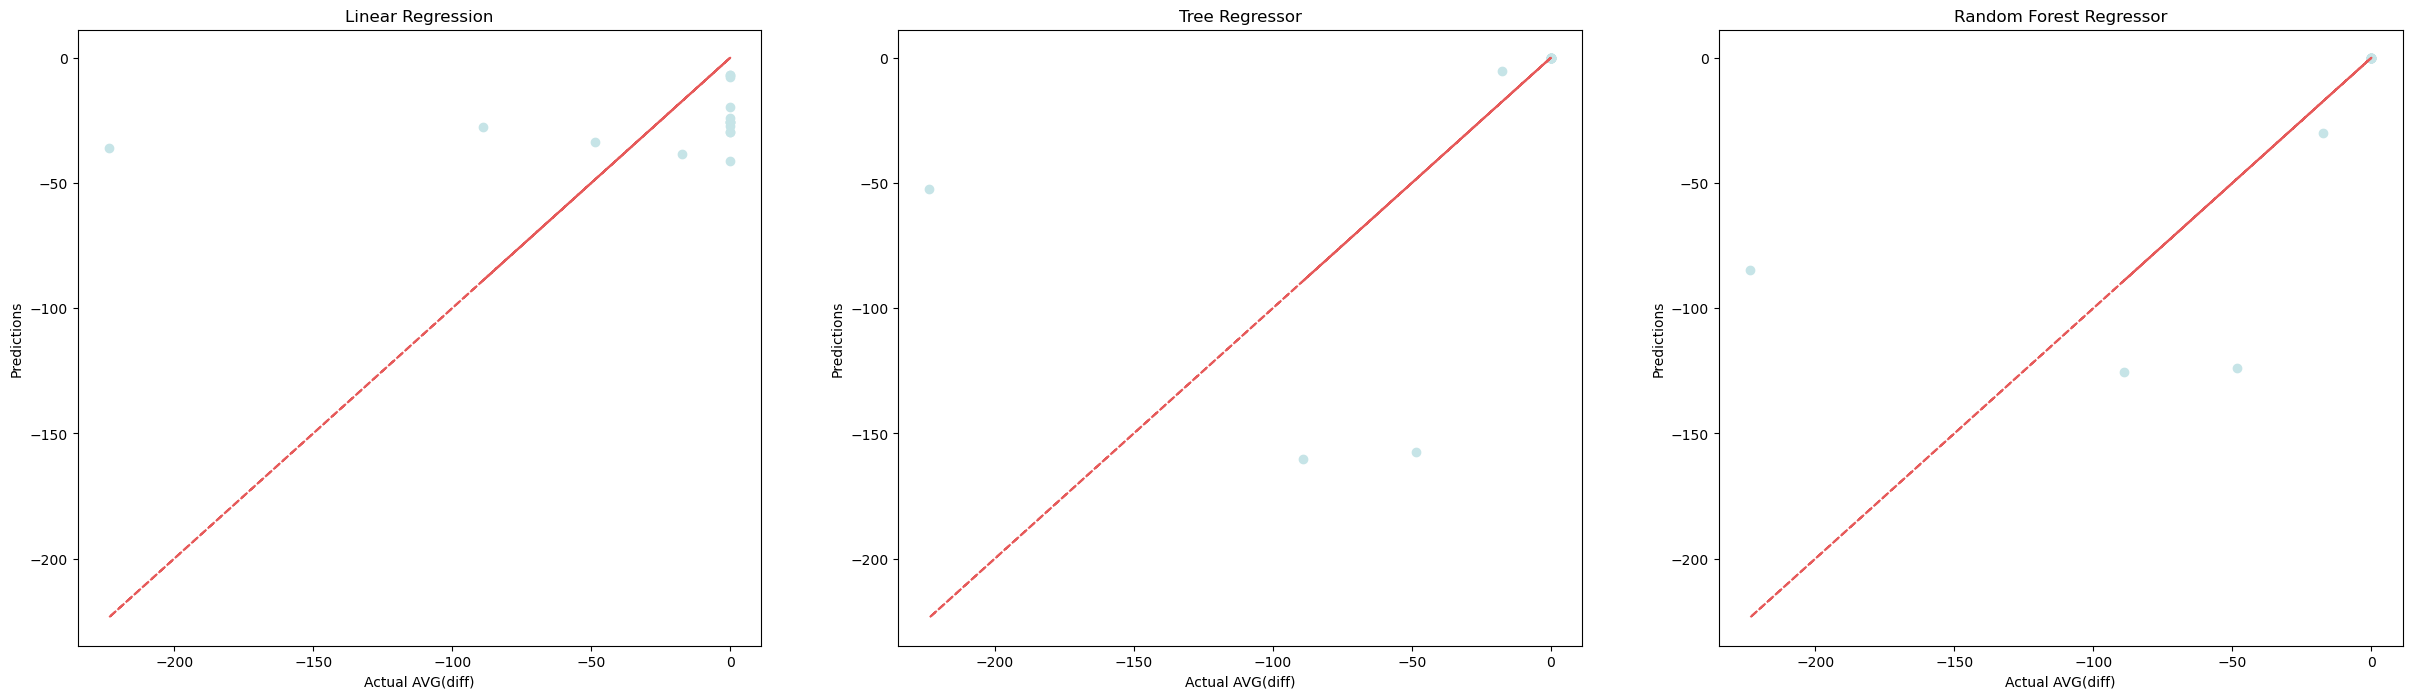

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))
# linear regression
ax[0].scatter(Y_test, reg_pred, color="#c6e4e7")
ax[0].set_title("Linear Regression")
ax[0].set_xlabel("Actual AVG(diff)")
ax[0].set_ylabel("Predictions")
ax[0].plot(Y_test, Y_test, color="#e65a5a", linestyle="--") # случай, когда все предсказания были верными

# tree regressor
ax[1].scatter(Y_test, tree_pred, color="#c6e4e7")
ax[1].set_title("Tree Regressor")
ax[1].set_xlabel("Actual AVG(diff)")
ax[1].set_ylabel("Predictions")
ax[1].plot(Y_test, Y_test, color="#e65a5a", linestyle="--") 

# random forest regressor
ax[2].scatter(Y_test, forest_pred, color="#c6e4e7")
ax[2].set_title("Random Forest Regressor")
ax[2].set_xlabel("Actual AVG(diff)")
ax[2].set_ylabel("Predictions")
ax[2].plot(Y_test, Y_test, color="#e65a5a", linestyle="--") 

plt.show()

In [11]:
predictions = pd.DataFrame(Y_test)
predictions["reg"] = reg_pred
predictions["tree"] = tree_pred
predictions["random forest"] = forest_pred

predictions

,AVG(diff),reg,tree,random forest
3,0.0,-27.158932,0.000000,0.000000
19,-17.5,-38.512614,-5.333333,-29.964333
14,-48.5,-33.597712,-157.400000,-123.756000
45,-223.6,-36.139903,-52.333333,-84.728000
10,0.0,-23.941954,0.000000,0.000000
54,0.0,-6.997094,0.000000,0.000000
23,0.0,-25.804072,0.000000,0.000000
29,0.0,-41.054959,0.000000,0.000000
24,0.0,-25.804072,0.000000,0.000000
13,-89.0,-27.835413,-160.400000,-125.467500


Из таблицы видно, что линейная регрессия хуже всех предсказала результаты; это объясняет и разное количество точек на графиках - на tree regressor и random forest regressor истинные значения часто соврадают с предсказаниями (преимущественно в точке 0), то есть накладываются друг на друга

__Answer:__
В идеальном случае (когда все предскания совпали с истинными занчениями) график должен напоминать y=x, то есть _диагональ_ (на рисунке отмечено красной линией)